# Logistic and Classification

In [4]:
# Import library
import pandas as pd # pengelolaan data
import numpy  as np # numeric, aritmethic

# Visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split  # Memisahkan data yang dilatih dan diuji
from sklearn.preprocessing import StandardScaler     # Untuk feature scaling (mengubah fitur ke skala yang sama)
from sklearn.linear_model import LogisticRegression  # Modeling dengan menggunakan logistic regresi
from sklearn.metrics import(
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)
from sklearn.datasets import load_breast_cancer, load_iris

In [5]:
data_bc  = load_breast_cancer(as_frame=True)
df_bc    = data_bc.frame
df_bc.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
df_bc.shape

(569, 31)

In [7]:
data_bc.target_names

array(['malignant', 'benign'], dtype='<U9')

In [10]:
# Memisahkan feature dan target
x  = df_bc.drop(columns=['target'])
y  = df_bc['target']

In [54]:
# Memisahkan data training dan data testing
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

x_train.shape, x_test.shape

((455, 30), (114, 30))

In [55]:
# Feature scaling

scaler = StandardScaler()

# Fit
x_train_scaled = scaler.fit_transform(x_train)  # Menstandarisasi dan diubah datanya 
x_test_scaled  = scaler.transform(x_test)       # Langsung mengubah ke standar default

In [56]:
# Model Regresi Logistik
log_reg = LogisticRegression(max_iter = 1000)
log_reg.fit(x_train_scaled, y_train)

y_train_pred = log_reg.predict(x_train_scaled)
y_test_pred = log_reg.predict(x_test_scaled)

In [57]:
print('Akurasi data train : ', accuracy_score(y_train, y_train_pred))
print('Akurasi data test  : ', accuracy_score(y_test, y_test_pred))

Akurasi data train :  0.989010989010989
Akurasi data test  :  0.9824561403508771


# Confusion Matrix

In [58]:
cm_bc = confusion_matrix(y_test, y_test_pred)
cm_bc

array([[41,  1],
       [ 1, 71]])

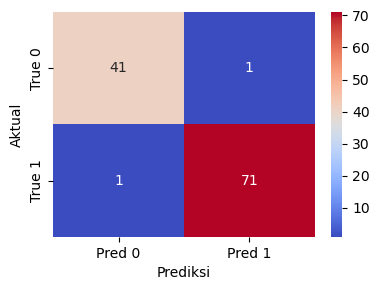

In [63]:
plt.figure(figsize=(4, 3))

sns.heatmap(
    cm_bc,
    annot=True,
    fmt='d',
    cmap='coolwarm',
    xticklabels=['Pred 0', 'Pred 1'],
    yticklabels=['True 0', 'True 1']
)

# plt.title("a")
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

# Classification Metrics
(Accuracy, Prediction, Recall, F1 Score, Specificity)

In [72]:
acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print(f'Accuracy Score  : ', acc)
print(f'Precision Score : ', prec)
print(f'Recall Score    : ', rec)
print(f'F1 Score        : ', f1)

Accuracy Score  :  0.9824561403508771
Precision Score :  0.9861111111111112
Recall Score    :  0.9861111111111112
F1 Score        :  0.9861111111111112


In [73]:
# Specificity
# Ambil nilai confusion matrix
TN, FP, FN, TP = cm_bc.ravel()
specificity = TN / (TN + FP)

print('Specificity : ', specificity)

Specificity :  0.9761904761904762


In [75]:
# Classification report
print(classification_report(y_test, y_test_pred))

NameError: name 'classification_report' is not defined